# Differential expression analysis


#### You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

#### Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


#### We would now like to understand exactly the difference between the expression in our groups of mice. Which pipeline would you use for this?

Suggestion: nf-core/differentialabundance

It takes the expression matrix from nf-core/rnaseq (Salmon), a samplesheet with the sample metadata (genotype and condition) and a contrasts file that defines which groups to compare (e.g. Sham-Oxy vs Sham-Sal). It then filters and normalizes the data, runs the differential expression analysis with DESeq2, and creates PCA plots, volcano plots, tables of the differentially expressed genes, optional gene set enrichment (GSEA) and an HTML report.

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

Differential abundance analysis for feature/ observation matrices from platforms such as RNA-seq

- samplesheet file can be tab or comma separated
- a column listing the sample IDs (must be the same IDs as in the abundance matrix)
- conditions for the differential analysis

In [2]:
import pandas as pd

counts = pd.read_csv("data/salmon.merged.gene_counts.tsv", sep="\t")

# sample names = all columns except the gene columns
samples = [c for c in counts.columns if c not in ["gene_id", "gene_name"]]
sheet = pd.DataFrame({"sample": samples})

# "Sham_oxy_1" -> Condition "Sham_oxy", genotype "Sham", treatment "oxy", replicate "1"
sheet["Condition"] = sheet["sample"].str.rsplit("_", n=1).str[0]
sheet["genotype"] = sheet["Condition"].str.split("_").str[0]
sheet["treatment"] = sheet["Condition"].str.split("_").str[1]

sheet.to_csv("samplesheet.csv", index=False)
sheet

,sample,Condition,genotype,treatment
0,Sham_oxy_1,Sham_oxy,Sham,oxy
1,Sham_oxy_2,Sham_oxy,Sham,oxy
2,Sham_oxy_3,Sham_oxy,Sham,oxy
3,Sham_oxy_4,Sham_oxy,Sham,oxy
4,Sham_Sal_1,Sham_Sal,Sham,Sal
5,Sham_Sal_2,Sham_Sal,Sham,Sal
6,Sham_Sal_3,Sham_Sal,Sham,Sal
7,Sham_Sal_4,Sham_Sal,Sham,Sal
8,SNI_oxy_1,SNI_oxy,SNI,oxy
9,SNI_oxy_2,SNI_oxy,SNI,oxy


Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [ ]:
!nextflow run nf-core/differentialabundance -r 2.0.0 -profile rnaseq,docker -c local.config \
    --input samplesheet.csv \
    --contrasts data/contrasts.csv \
    --matrix data/salmon.merged.gene_counts.tsv \
    --features_id_col gene_id \
    --features_name_col gene_name \
    --features_metadata_cols gene_id,gene_name \
    --exploratory_main_variable Condition \
    --outdir results \
    -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [chaotic_shirley] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : samplesheet.csv
  contrasts                   : data/contrasts.csv
  outdir                      : results
  study_abundance_type        : counts

[base] Abundance values
  matrix                      : data/salmon.merged.gene_counts.tsv

[base] Observations (e.g. samp

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

| Parameter | Explanation |
|---|---|
| `nextflow run nf-core/differentialabundance` | Pipeline for differential expression analysis |
| `-r 2.0.0` | Fixed pipeline version for reproducibility |
| `-profile rnaseq,docker` | `rnaseq` sets defaults for RNA-seq count data (DESeq2); `docker` runs all tools in containers |
| `-c local.config` | Limits CPUs and memory to what is available on the laptop |
| `--input samplesheet.csv` | Sample metadata: one row per sample with its group (`Condition`), genotype and treatment; sample names must match the matrix columns |
| `--contrasts data/contrasts.csv` | Defines which groups are compared: SNI_oxy vs SNI_Sal and Sham_oxy vs Sham_Sal |
| `--matrix` | Gene count matrix from nf-core/rnaseq (Salmon): genes in rows, samples in columns |
| `--features_id_col`, `--features_name_col`, `--features_metadata_cols` | No GTF file was provided, so gene IDs and names are taken directly from the matrix |
| `--exploratory_main_variable Condition` | Colours the report plots by the 4 groups; without it the report crashed |
| `--outdir results` | Folder where all results are saved |

What were the outputs of the pipeline?

In [ ]:

!ls results
!ls results/tables/differential/rnaseq

other  pipeline_info  plots  report  shinyngs_app  tables
condition_control_treated_study.deseq2.results.tsv
condition_control_treated_study.deseq2.results_filtered.tsv
condition_control_treated_study_deseq2.annotated.tsv
condition_control_treated_test_study.deseq2.results.tsv
condition_control_treated_test_study.deseq2.results_filtered.tsv
condition_control_treated_test_study_deseq2.annotated.tsv


The most important outputs are:

HTML report (report/): shows the whole analysis on one page. It includes an overview of the samples, quality control plots (PCA, sample clustering, count distributions) and, for each comparison, a volcano plot and a table of the changed genes.

DESeq2 result tables (tables/differential/): list the log2 fold change, the p-value and the adjusted p-value for every gene in each comparison. The results_filtered files contain only the significant genes. These gene lists are used for all further steps, for example comparing the contrasts or a pathway analysis.

Normalised count tables (tables/processed_abundance/): the counts are adjusted so that the samples can be compared with each other. They are used for plots like the PCA and heatmaps.

![PCA](images/pca.png)

The PCA shows that most samples form one group and the four conditions do not separate clearly,
so the treatment effect on gene expression is small compared to the variation between individual mice.
SNI_Sal_2 (and to a lesser degree SNI_Sal_4) lies far away from all other samples,
so one can assume a technical outlier.

![Sample clustering](images/dendrogram.png)

The dendrogram groups the samples by the similarity of their 500 most variable genes. The first split separates SNI_Sal_2 and SNI_Sal_4 from all other samples, which confirms them as outliers, while the remaining samples are mostly mixed across conditions, showing that the treatment effect is small

![Volcano plot SNI](images/volcano_SNI.png)

The volcano plot compares SNI_oxy with SNI_Sal: only a few genes are significant, and almost all of them are lower in the oxycodone group (negative log2 fold change); only Top2a is higher. The strongest hits are
ribosomal RNA-related genes (Rn18s-rs5, n-R5-8s1, Lars2) and unannotated genes (Gm…, …Rik), which are more likely a technical effect of the outlier samples SNI_Sal_2/4 than a biological effect of withdrawal.

![Volcano plot Sham](images/volcano_Sham.png)

The volcano plot compares Sham_oxy with Sham_Sal: only 7 genes pass both thresholds, and all of them are higher in the oxycodone group, including dopamine-related genes such as Slc6a3 (dopamine transporter) and Ret. Many more genes are significant (above the line) but have only small fold changes ,so withdrawal causes mostly subtle expression changes in mice without pain.


Would you exclude any samples? If yes, which and why?

Yes, I would exclude SNI_Sal_2 and SNI_Sal_4, because both are clear outliers in the PCA and form a separate branch in the sample clustering. SNI_Sal_2 also has the fewest detected genes, and both samples seem to cause technical artefacts such as rRNA genes appearing as differentially expressed. However, this reduces the SNI_Sal group to only 2 samples, which lowers the statistical power.

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

In [7]:
import pandas as pd

folder = "results/tables/differential/rnaseq/"
contrasts = {
    "SNI_oxy vs SNI_Sal": "condition_control_treated_study",
    "Sham_oxy vs Sham_Sal": "condition_control_treated_test_study",
}

for name, prefix in contrasts.items():
    sig = pd.read_csv(folder + prefix + ".deseq2.results_filtered.tsv", sep="\t")
    up = (sig["log2FoldChange"] > 0).sum()
    down = (sig["log2FoldChange"] < 0).sum()
    print(f"{name}: {len(sig)} DE genes ({up} up, {down} down)")

SNI_oxy vs SNI_Sal: 18 DE genes (1 up, 17 down)
Sham_oxy vs Sham_Sal: 7 DE genes (7 up, 0 down)


The course gave two comparisons: oxycodone vs saline in SNI mice, and oxycodone vs saline in Sham mice. The paper compares every group to Sham-Sal instead. Because the comparisons are different, the numbers cannot be compared directly with the paper.

In mice with nerve injury, 18 genes were differentially expressed between oxycodone and saline (1 higher, 17 lower with oxycodone). In mice without nerve injury, 7 genes were differentially expressed, all higher with oxycodone. The two gene lists do not overlap.

This only partly confirms the paper. Like the paper, we find that the withdrawal response differs between mice with and without chronic pain, but we find far fewer changed genes. This is probably because we analysed only one brain region with four samples per group, used strict thresholds, and included two outlier samples that add technical noise, for example ribosomal RNA genes.

##### The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

The three regions are part of the brain's reward system.

The nucleus accumbens (NAc) is part of the ventral striatum and processes reward, motivation and pleasure. It plays a key role in addiction.

The medial prefrontal cortex (mPFC) is part of the frontal cortex and controls decision-making, emotions and behaviour. It regulates the reward system and is involved in craving and relapse.

The ventral tegmental area (VTA) is a midbrain region with dopamine neurons. It sends dopamine to the nucleus accumbens and the prefrontal cortex and is the starting point of the reward pathway.

##### Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

Not from the paper alone. According to the Methods, samples were taken from the NAc, mPFC and VTA but the paper only reports the number of differentially expressed genes per region and does not provide the gene lists; other data are only "available upon request".


##### Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

No just communicating the list of differentially expressed genes is bot sufficient. A gene list alone is hard to interpret, so it should come with pathway analysis and quality information. The paper used pathway analysis to predict HDAC1 as a key regulator and then confirmed it experimentally with an HDAC1/HDAC2 inhibitor, which reduced withdrawal symptoms.

I ran the analysis twice: first with the pipeline defaults (adjusted p-value < 0.05, |log2 fold change| > 1, with fold-change shrinkage), and then with the criteria from the paper (nominal p-value < 0.05, |log2 fold change| > 0.5, without shrinkage) to make the results more comparable.

In [11]:
!nextflow run nf-core/differentialabundance -r 2.0.0 -profile rnaseq,docker -c local.config \
    -params-file params.yaml \
    --input samplesheet.csv \
    --contrasts data/contrasts.csv \
    --matrix data/salmon.merged.gene_counts.tsv \
    --features_id_col gene_id \
    --features_name_col gene_name \
    --features_metadata_cols gene_id,gene_name \
    --outdir results_paper \
    -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [trusting_galileo] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : samplesheet.csv
  contrasts                   : data/contrasts.csv
  outdir                      : results_paper
  study_abundance_type        : counts

[base] Abundance values
  matrix                      : data/salmon.merged.gene_counts.tsv

[base] Observations (e.

| Parameter | Explanation |
|---|---|
| `-params-file params.yaml` | Loads settings from a file (true/false and numbers on the command line are read as text). It contains: `deseq2_shrink_lfc: false` (no fold-change shrinkage, as in the paper), `differential_max_pval: 0.05` and `differential_max_qval: 1.0` (select genes by nominal p-value < 0.05, as in the paper), `differential_min_fold_change: 1.41421` (\|log2 fold change\| > 0.5, as in the paper) and `exploratory_main_variable: Condition` (colours the report plots by the 4 groups; without it the report crashed) |
| `-resume` | Reuses finished steps from the previous run |


In [ ]:
paper_folder = "results_paper/tables/differential/rnaseq/"
for name, p in {"SNI: Oxy vs Sal": "condition_control_treated_study",
                  "Sham: Oxy vs Sal": "condition_control_treated_test_study"}.items():
      res = pd.read_csv(paper_folder + p + ".deseq2.results.tsv", sep="\t")
      sig = res[(res["pvalue"] < 0.05) & (res["log2FoldChange"].abs() > 0.5)]
      print(f"{name}: {len(sig)} genes ({(sig['log2FoldChange'] > 0).sum()} up, {(sig['log2FoldChange'] < 0).sum()} down)")

SNI: Oxy vs Sal: 804 genes (178 up, 626 down)
Sham: Oxy vs Sal: 1205 genes (869 up, 336 down)


Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentionned.

Pipeline defaults | adjusted p < 0.05, |log2FC| > 1, shrinkage -> [18, 7] shared: 0
Paper settings | raw p < 0.05, |log2FC| > 0.5, no shrinkage -> [804, 1205] shared: 104


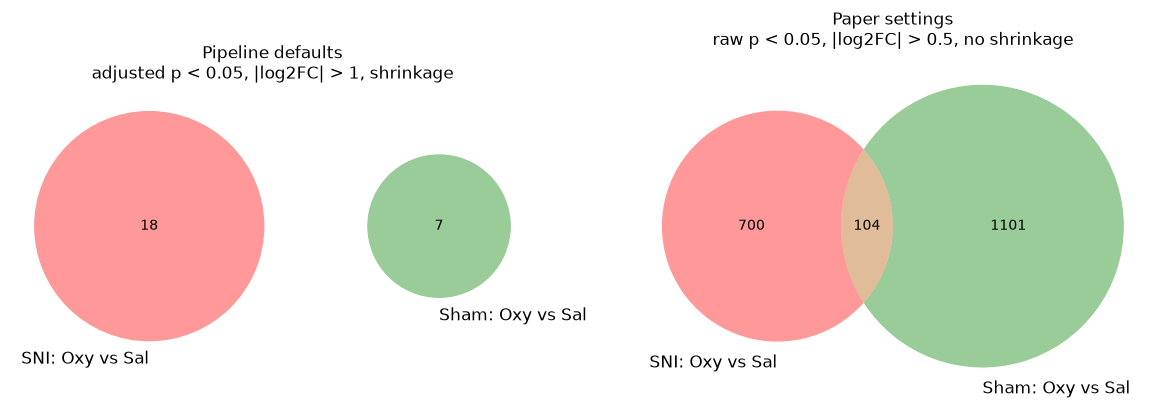

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

contrasts = {
    "SNI: Oxy vs Sal": "condition_control_treated_study",
    "Sham: Oxy vs Sal": "condition_control_treated_test_study",
}

# Left: first run with pipeline defaults (the filtered tables = the 18 and 7 genes)
default_folder = "results/tables/differential/rnaseq/"
sets_default = [set(pd.read_csv(default_folder + p + ".deseq2.results_filtered.tsv", sep="\t")["gene_id"])
                for p in contrasts.values()]

# Right: second run with the paper's settings (raw p < 0.05, |log2FC| > 0.5, no shrinkage)
paper_folder = "results_paper/tables/differential/rnaseq/"
sets_paper = []
for p in contrasts.values():
    res = pd.read_csv(paper_folder + p + ".deseq2.results.tsv", sep="\t")
    sets_paper.append(set(res.loc[(res["pvalue"] < 0.05) & (res["log2FoldChange"].abs() > 0.5), "gene_id"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, sets, title in zip(axes, [sets_default, sets_paper],
                           ["Pipeline defaults\nadjusted p < 0.05, |log2FC| > 1, shrinkage",
                            "Paper settings\nraw p < 0.05, |log2FC| > 0.5, no shrinkage"]):
    venn2(sets, set_labels=list(contrasts.keys()), ax=ax)
    ax.set_title(title)
    print(title.replace("\n", " | "), "->", [len(s) for s in sets], "shared:", len(sets[0] & sets[1]))

plt.tight_layout()
plt.savefig("images/venn_paper.png", dpi=150, bbox_inches="tight")
plt.show()

The Venn diagrams compare the differentially expressed genes of the two provided contrasts.
The left diagram shows the first run with the pipeline defaults (adjusted p-value < 0.05, |log2 fold change| > 1,
with fold-change shrinkage): 18 genes (SNI) and 7 genes (Sham) are differentially expressed, and none are shared.
The right diagram shows the second run with the settings from the paper (raw p-value < 0.05,
|log2 fold change| > 0.5, no shrinkage): we find 804 and 1205 genes, of which 104 are shared.

So the choice of settings changes the result a lot: with the paper's settings we get numbers in the same range
as the paper, but many of these genes are likely false positives, because about 20,000 genes are tested without
correction for multiple testing. In both cases, most genes change only in one pain state, which supports the
paper's finding that chronic pain changes the response to oxycodone withdrawal. Unlike Figure 3, we used the two
provided contrasts instead of comparing each group to Sham-Sal, so the diagrams are not directly comparable.